<a href="https://colab.research.google.com/github/AliAsad077/todo_app/blob/main/initial_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# STEP 0: Environment Setup
# ============================================

import torch
import numpy as np
import random
import os

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ---- Check GPU ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ No GPU found. Go to Runtime > Change runtime type > GPU (T4).")

# ---- Install required packages (Colab usually has most already) ----
!pip install -q opencv-python-headless scikit-image

# ---- Imports we'll need throughout the notebook ----
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ---- Mount Google Drive (to save checkpoints / cache the dataset) ----
from google.colab import drive
drive.mount('/content/drive')

# ---- Create working folders ----
os.makedirs('/content/data', exist_ok=True)
os.makedirs('/content/drive/MyDrive/sa_mil_project/checkpoints', exist_ok=True)

print("✅ Step 0 complete. Environment ready.")

Using device: cuda
GPU: Tesla T4
Mounted at /content/drive
✅ Step 0 complete. Environment ready.


In [1]:
# ============================================
# STEP 1a: Inspect your Drive dataset structure first
# ============================================

import os

BASE_DIR = "/content/drive/MyDrive/breast"

print(f"Does the path exist? {os.path.exists(BASE_DIR)}\n")

# Print folder tree up to 4 levels deep, with file counts, so we can
# see how it's organized before writing the parser
def print_tree(path, prefix="", max_depth=4, depth=0):
    if depth > max_depth:
        return
    try:
        entries = sorted(os.listdir(path))
    except PermissionError:
        return
    dirs = [e for e in entries if os.path.isdir(os.path.join(path, e))]
    files = [e for e in entries if os.path.isfile(os.path.join(path, e))]

    if files:
        print(f"{prefix}[{len(files)} files] e.g. {files[0]}")

    for d in dirs[:10]:  # limit to first 10 subfolders per level to avoid huge output
        print(f"{prefix}{d}/")
        print_tree(os.path.join(path, d), prefix + "  ", max_depth, depth + 1)
    if len(dirs) > 10:
        print(f"{prefix}... and {len(dirs)-10} more folders")

print_tree(BASE_DIR)

Does the path exist? True

[2 files] e.g. README.txt
benign/
  [6 files] e.g. README_B.txt
  SOB/
    adenosis/
      SOB_B_A_14-22549AB/
        100X/
        200X/
        400X/
        40X/
      SOB_B_A_14-22549CD/
        100X/
        200X/
        400X/
        40X/
      SOB_B_A_14-22549G/
        100X/
        200X/
        400X/
        40X/
      SOB_B_A_14-29960CD/
        100X/
        200X/
        400X/
        40X/
    fibroadenoma/
      SOB_B_F_14-14134/
        100X/
        200X/
        400X/
        40X/
      SOB_B_F_14-14134E/
        100X/
        200X/
        400X/
        40X/
      SOB_B_F_14-21998CD/
        100X/
        200X/
        400X/
        40X/
      SOB_B_F_14-21998EF/
        100X/
        200X/
        400X/
        40X/
      SOB_B_F_14-23060AB/
        100X/
        200X/
        400X/
        40X/
      SOB_B_F_14-23060CD/
        100X/
        200X/
        400X/
        40X/
      SOB_B_F_14-23222AB/
        100X/
        200X/
        40

In [2]:
# ============================================
# STEP 1b: Parse BreakHis directly from Drive
# ============================================

import os
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/breast"

records = []

for tumor_class_folder in ["benign", "malignant"]:
    class_path = os.path.join(BASE_DIR, tumor_class_folder)
    sob_path = os.path.join(class_path, "SOB")
    if not os.path.exists(sob_path):
        print(f"⚠️ Warning: {sob_path} not found, skipping.")
        continue

    label = 1 if tumor_class_folder == "malignant" else 0

    for tumor_type in os.listdir(sob_path):
        tumor_type_path = os.path.join(sob_path, tumor_type)
        if not os.path.isdir(tumor_type_path):
            continue

        for slide_folder in os.listdir(tumor_type_path):
            slide_path = os.path.join(tumor_type_path, slide_folder)
            if not os.path.isdir(slide_path):
                continue

            for mag_folder in os.listdir(slide_path):
                # mag_folder looks like "40X", "100X", "200X", "400X"
                mag_path = os.path.join(slide_path, mag_folder)
                if not os.path.isdir(mag_path):
                    continue

                mag_digits = "".join(filter(str.isdigit, mag_folder))
                if not mag_digits:
                    continue
                magnification = int(mag_digits)

                for fname in os.listdir(mag_path):
                    if not fname.lower().endswith(".png"):
                        continue
                    records.append({
                        "image_path": os.path.join(mag_path, fname),
                        "label": label,                      # 1 = malignant, 0 = benign
                        "tumor_class": "M" if label == 1 else "B",
                        "tumor_type": tumor_type,
                        "slide_id": slide_folder,             # unique per patient/slide
                        "magnification": magnification,
                    })

df = pd.DataFrame(records)
print(f"Total images parsed: {len(df)}")
df.head()

Total images parsed: 7909


,image_path,label,tumor_class,tumor_type,slide_id,magnification
0,/content/drive/MyDrive/breast/benign/SOB/tubul...,0,B,tubular_adenoma,SOB_B_TA_14-16184CD,400
1,/content/drive/MyDrive/breast/benign/SOB/tubul...,0,B,tubular_adenoma,SOB_B_TA_14-16184CD,400
2,/content/drive/MyDrive/breast/benign/SOB/tubul...,0,B,tubular_adenoma,SOB_B_TA_14-16184CD,400
3,/content/drive/MyDrive/breast/benign/SOB/tubul...,0,B,tubular_adenoma,SOB_B_TA_14-16184CD,400
4,/content/drive/MyDrive/breast/benign/SOB/tubul...,0,B,tubular_adenoma,SOB_B_TA_14-16184CD,400


In [3]:
# ---- Inspect stats ----

print("Class balance (all magnifications):")
print(df["label"].value_counts().rename({0: "benign", 1: "malignant"}))

print("\nMagnifications found:")
print(df["magnification"].value_counts())

print("\nTumor type breakdown:")
print(df["tumor_type"].value_counts())

print(f"\nUnique slide_ids (all mags): {df['slide_id'].nunique()}")

Class balance (all magnifications):
label
malignant    5429
benign       2480
Name: count, dtype: int64

Magnifications found:
magnification
100    2081
200    2013
40     1995
400    1820
Name: count, dtype: int64

Tumor type breakdown:
tumor_type
ductal_carcinoma       3451
fibroadenoma           1014
mucinous_carcinoma      792
lobular_carcinoma       626
tubular_adenoma         569
papillary_carcinoma     560
phyllodes_tumor         453
adenosis                444
Name: count, dtype: int64

Unique slide_ids (all mags): 82


In [4]:
# ---- Filter to one magnification (40X) for our first pass ----

MAGNIFICATION = 40  # change to 100/200/400 later if you want to compare

df_mag = df[df["magnification"] == MAGNIFICATION].reset_index(drop=True)

print(f"Images at {MAGNIFICATION}X: {len(df_mag)}")
print("\nClass balance at this magnification:")
print(df_mag["label"].value_counts().rename({0: "benign", 1: "malignant"}))
print(f"\nUnique slide_ids at {MAGNIFICATION}X: {df_mag['slide_id'].nunique()}")

# Save for later steps
df.to_csv("/content/data/breakhis_all_magnifications.csv", index=False)
df_mag.to_csv("/content/data/breakhis_40x.csv", index=False)
print("\n✅ Step 1 complete. Saved breakhis_40x.csv and breakhis_all_magnifications.csv")

Images at 40X: 1995

Class balance at this magnification:
label
malignant    1370
benign        625
Name: count, dtype: int64

Unique slide_ids at 40X: 82

✅ Step 1 complete. Saved breakhis_40x.csv and breakhis_all_magnifications.csv


In [5]:
# ============================================
# STEP 2a: Slide-level train/val/test split
# ============================================

from sklearn.model_selection import train_test_split
import pandas as pd

df_mag = pd.read_csv("/content/data/breakhis_40x.csv")

# ---- Build a slide-level table (one row per slide_id) so we split
#      PATIENTS, not images, avoiding leakage ----
slide_table = df_mag.groupby("slide_id").agg(
    label=("label", "first"),      # each slide is entirely benign or malignant
    tumor_type=("tumor_type", "first"),
    n_images=("image_path", "count")
).reset_index()

print(f"Total slides: {len(slide_table)}")
print(slide_table["label"].value_counts().rename({0: "benign", 1: "malignant"}))

# ---- Split slide_ids: 70% train, 15% val, 15% test ----
train_slides, temp_slides = train_test_split(
    slide_table, test_size=0.30, stratify=slide_table["label"], random_state=42
)
val_slides, test_slides = train_test_split(
    temp_slides, test_size=0.50, stratify=temp_slides["label"], random_state=42
)

print(f"\nSlides -> train: {len(train_slides)}, val: {len(val_slides)}, test: {len(test_slides)}")

# ---- Sanity check: no overlap between splits ----
assert set(train_slides["slide_id"]) & set(val_slides["slide_id"]) == set()
assert set(train_slides["slide_id"]) & set(test_slides["slide_id"]) == set()
assert set(val_slides["slide_id"]) & set(test_slides["slide_id"]) == set()
print("✅ No slide_id overlap between splits.")

# ---- Assign every IMAGE to whichever split its slide_id belongs to ----
train_df = df_mag[df_mag["slide_id"].isin(train_slides["slide_id"])].reset_index(drop=True)
val_df   = df_mag[df_mag["slide_id"].isin(val_slides["slide_id"])].reset_index(drop=True)
test_df  = df_mag[df_mag["slide_id"].isin(test_slides["slide_id"])].reset_index(drop=True)

print(f"\nImages -> train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")
print("\nTrain class balance:", train_df["label"].value_counts().to_dict())
print("Val class balance:  ", val_df["label"].value_counts().to_dict())
print("Test class balance: ", test_df["label"].value_counts().to_dict())

# ---- Save splits ----
train_df.to_csv("/content/data/train.csv", index=False)
val_df.to_csv("/content/data/val.csv", index=False)
test_df.to_csv("/content/data/test.csv", index=False)
print("\n✅ Saved train.csv, val.csv, test.csv")

Total slides: 82
label
malignant    58
benign       24
Name: count, dtype: int64

Slides -> train: 57, val: 12, test: 13
✅ No slide_id overlap between splits.

Images -> train: 1365, val: 283, test: 347

Train class balance: {1: 973, 0: 392}
Val class balance:   {1: 215, 0: 68}
Test class balance:  {1: 182, 0: 165}

✅ Saved train.csv, val.csv, test.csv


In [6]:
# ============================================
# STEP 2b: PyTorch Dataset class
# ============================================

import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class BreakHisDataset(Dataset):
    def __init__(self, csv_path, image_size=256, train=False):
        self.df = pd.read_csv(csv_path)
        self.train = train

        if train:
            self.transform = T.Compose([
                T.Resize((image_size, image_size)),
                T.RandomHorizontalFlip(p=0.5),
                T.RandomVerticalFlip(p=0.5),
                T.RandomRotation(degrees=15),
                T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
                T.ToTensor(),
                T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ])
        else:
            self.transform = T.Compose([
                T.Resize((image_size, image_size)),
                T.ToTensor(),
                T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        image = self.transform(image)
        label = torch.tensor(row["label"], dtype=torch.float32)
        return image, label

# ---- Quick sanity check ----
train_ds = BreakHisDataset("/content/data/train.csv", train=True)
val_ds   = BreakHisDataset("/content/data/val.csv", train=False)
test_ds  = BreakHisDataset("/content/data/test.csv", train=False)

img, label = train_ds[0]
print(f"Sample image shape: {img.shape}, label: {label.item()}")
print(f"Train size: {len(train_ds)}, Val size: {len(val_ds)}, Test size: {len(test_ds)}")

Sample image shape: torch.Size([3, 256, 256]), label: 0.0
Train size: 1365, Val size: 283, Test size: 347


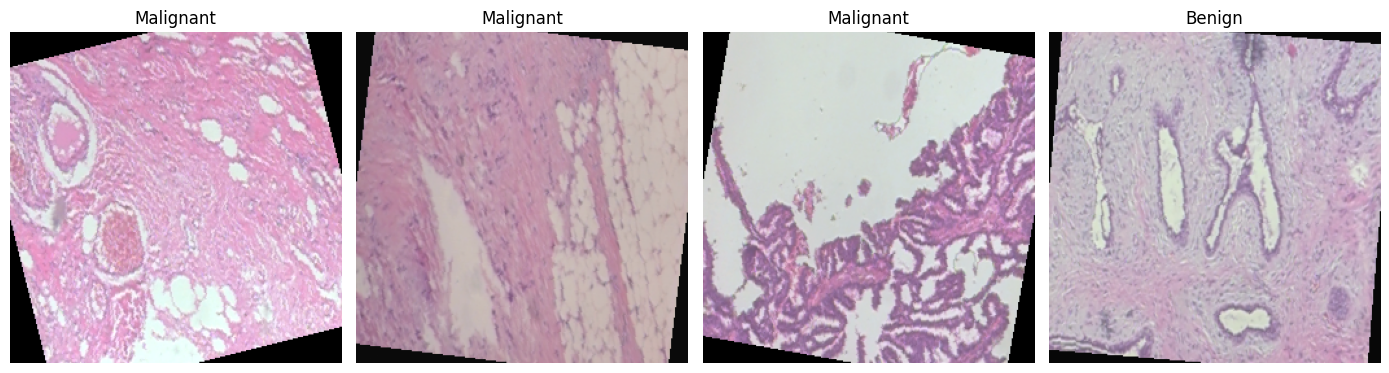


✅ Step 2 complete. DataLoaders ready.


In [7]:
# ============================================
# STEP 2c: DataLoaders
# ============================================

BATCH_SIZE = 8

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)

# ---- Visual sanity check: show a few training images with labels ----
import matplotlib.pyplot as plt

def denormalize(img_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i in range(4):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].set_title("Malignant" if labels[i] == 1 else "Benign")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

print("\n✅ Step 2 complete. DataLoaders ready.")

In [8]:
# ============================================
# STEP 3: VGG-16 Backbone — first 3 stages
# ============================================

import torch
import torch.nn as nn
import torchvision.models as models

class VGGBackbone(nn.Module):
    """
    Extracts the first 3 convolutional stages of VGG-16 (pretrained on
    ImageNet), matching the SA-MIL paper's design. Each 'stage' here
    means: the conv layers of that VGG block, WITHOUT its pooling layer.
    We keep pooling separate so we can insert a Self-Attention Module
    (Step 4) between conv and pool at each stage.

    VGG-16 features (torchvision indexing) look like:
      Stage 1: conv(0) relu(1) conv(2) relu(3) | pool(4)
      Stage 2: conv(5) relu(6) conv(7) relu(8) | pool(9)
      Stage 3: conv(10) relu(11) conv(12) relu(13) conv(14) relu(15) | pool(16)
    """
    def __init__(self, pretrained=True):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1 if pretrained else None)
        features = vgg.features

        # Stage 1: conv layers only (indices 0-3), pool separate (index 4)
        self.stage1_conv = nn.Sequential(*features[0:4])
        self.pool1 = features[4]

        # Stage 2: conv layers only (indices 5-8), pool separate (index 9)
        self.stage2_conv = nn.Sequential(*features[5:9])
        self.pool2 = features[9]

        # Stage 3: conv layers only (indices 10-15), pool separate (index 16)
        self.stage3_conv = nn.Sequential(*features[10:16])
        self.pool3 = features[16]

    def forward(self, x):
        """
        Returns a list of 3 feature maps — the CONV output of each stage
        BEFORE pooling. In Step 5 we'll insert SAM here, then pool.
        For now (Step 3 only), we just pool immediately to verify shapes.
        """
        s1 = self.stage1_conv(x)
        p1 = self.pool1(s1)

        s2 = self.stage2_conv(p1)
        p2 = self.pool2(s2)

        s3 = self.stage3_conv(p2)
        p3 = self.pool3(s3)

        return [s1, s2, s3], [p1, p2, p3]


# ---- Quick shape test with a 256x256 input ----
backbone = VGGBackbone(pretrained=True)
backbone.eval()

dummy_input = torch.randn(2, 3, 256, 256)  # batch of 2 images
with torch.no_grad():
    pre_pool_feats, post_pool_feats = backbone(dummy_input)

print("Feature map shapes BEFORE pooling (these get SAM inserted on them):")
for i, feat in enumerate(pre_pool_feats, 1):
    print(f"  Stage {i}: {feat.shape}  (channels={feat.shape[1]}, spatial={feat.shape[2]}x{feat.shape[3]})")

print("\nFeature map shapes AFTER pooling (fed into next stage):")
for i, feat in enumerate(post_pool_feats, 1):
    print(f"  Stage {i}: {feat.shape}")

print("\n✅ Step 3 complete. Backbone produces 3 stages as expected.")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 71.4MB/s]


Feature map shapes BEFORE pooling (these get SAM inserted on them):
  Stage 1: torch.Size([2, 64, 256, 256])  (channels=64, spatial=256x256)
  Stage 2: torch.Size([2, 128, 128, 128])  (channels=128, spatial=128x128)
  Stage 3: torch.Size([2, 256, 64, 64])  (channels=256, spatial=64x64)

Feature map shapes AFTER pooling (fed into next stage):
  Stage 1: torch.Size([2, 64, 128, 128])
  Stage 2: torch.Size([2, 128, 64, 64])
  Stage 3: torch.Size([2, 256, 32, 32])

✅ Step 3 complete. Backbone produces 3 stages as expected.


In [9]:
# ============================================
# STEP 4: Criss-Cross Attention (CCA) Module
# ============================================

import torch
import torch.nn as nn
import torch.nn.functional as F


def _inf_mask(batch, height, width, device):
    """
    Creates a mask of -inf values so that, in the energy computation,
    a pixel never attends to itself twice (once via horizontal pass,
    once via vertical pass) — standard trick from the original CCNet.
    """
    return -torch.diag(torch.tensor(float("inf")).repeat(height), 0) \
        .unsqueeze(0).repeat(batch * width, 1, 1).to(device)


class CrissCrossAttention(nn.Module):
    """
    A single criss-cross attention pass.
    Input:  H  of shape (B, C, height, width)
    Output: H' of shape (B, C, height, width)  -- same shape, contextualized

    Steps (matches paper Section 3.2 / Fig. 5):
      1. Q, K = 1x1 conv, reduced to C//8 channels (dimension reduction)
      2. V     = 1x1 conv, full C channels
      3. Affinity: for each pixel, compute similarity with all pixels
         in its own ROW and COLUMN only (not full image) -> attention map A
      4. Aggregation: weighted sum of V using A -> contextual features
      5. Residual: add back the original input H
    """
    def __init__(self, in_channels):
        super().__init__()
        reduced_channels = max(in_channels // 8, 1)
        self.query_conv = nn.Conv2d(in_channels, reduced_channels, kernel_size=1)
        self.key_conv   = nn.Conv2d(in_channels, reduced_channels, kernel_size=1)
        self.value_conv = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.softmax = nn.Softmax(dim=3)
        # gamma starts at 0 so the module starts as an identity function,
        # and the network learns how much attention to actually use
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        B, C, H, W = x.size()

        Q = self.query_conv(x)  # (B, C*, H, W)
        K = self.key_conv(x)    # (B, C*, H, W)
        V = self.value_conv(x)  # (B, C,  H, W)

        # ---- Reshape for the horizontal (row-wise) pass ----
        Q_h = Q.permute(0, 3, 1, 2).contiguous().view(B * W, -1, H).permute(0, 2, 1)
        K_h = K.permute(0, 3, 1, 2).contiguous().view(B * W, -1, H)
        V_h = V.permute(0, 3, 1, 2).contiguous().view(B * W, -1, H)

        # ---- Reshape for the vertical (column-wise) pass ----
        Q_w = Q.permute(0, 2, 1, 3).contiguous().view(B * H, -1, W).permute(0, 2, 1)
        K_w = K.permute(0, 2, 1, 3).contiguous().view(B * H, -1, W)
        V_w = V.permute(0, 2, 1, 3).contiguous().view(B * H, -1, W)

        # ---- Affinity (energy) scores ----
        energy_h = (torch.bmm(Q_h, K_h) + _inf_mask(B, H, W, x.device)) \
            .view(B, W, H, H).permute(0, 2, 1, 3)   # (B, H, W, H)
        energy_w = torch.bmm(Q_w, K_w).view(B, H, W, W)  # (B, H, W, W)

        # ---- Softmax jointly over row+column candidates (this is the
        #      "Generalized Mean"-style softmax mentioned in the CCA figure) ----
        concate = self.softmax(torch.cat([energy_h, energy_w], dim=3))  # (B, H, W, H+W)
        att_h = concate[:, :, :, 0:H].permute(0, 2, 1, 3).contiguous().view(B * W, H, H)
        att_w = concate[:, :, :, H:H + W].contiguous().view(B * H, W, W)

        # ---- Aggregation: weighted sum of V using attention weights ----
        out_h = torch.bmm(V_h, att_h.permute(0, 2, 1)).view(B, W, -1, H).permute(0, 2, 3, 1)
        out_w = torch.bmm(V_w, att_w.permute(0, 2, 1)).view(B, H, -1, W).permute(0, 2, 1, 3)

        # ---- Residual connection ----
        return self.gamma * (out_h + out_w) + x


class SelfAttentionModule(nn.Module):
    """
    Wraps CrissCrossAttention and runs it TWICE in a loop (Fig. 3/5:
    'Two-loop Criss-Cross Attention'). After 2 passes, every pixel has
    indirectly gathered context from the ENTIRE image, not just its own
    row/column, while staying much cheaper than full self-attention.
    """
    def __init__(self, in_channels, loops=2):
        super().__init__()
        self.loops = loops
        self.cca = CrissCrossAttention(in_channels)

    def forward(self, x):
        for _ in range(self.loops):
            x = self.cca(x)
        return x


# ============================================
# Unit test — confirm output shape matches input shape
# ============================================
test_input = torch.randn(2, 64, 32, 32)
sam_test = SelfAttentionModule(in_channels=64, loops=2)
sam_test.eval()

with torch.no_grad():
    test_output = sam_test(test_input)

print(f"Input shape:  {test_input.shape}")
print(f"Output shape: {test_output.shape}")
assert test_output.shape == test_input.shape, "❌ Shape mismatch!"
print("✅ Step 4 complete. SAM preserves shape and runs without error.")

Input shape:  torch.Size([2, 64, 32, 32])
Output shape: torch.Size([2, 64, 32, 32])
✅ Step 4 complete. SAM preserves shape and runs without error.


In [10]:
# ============================================
# STEP 5: Backbone + Self-Attention (SAM at every stage)
# ============================================

import torch
import torch.nn as nn
import torchvision.models as models


class SAMILBackbone(nn.Module):
    """
    Combines VGG-16's first 3 stages with a SelfAttentionModule inserted
    between the conv layers and the pooling layer of EACH stage:

        input -> [conv1 -> SAM1 -> pool1] -> [conv2 -> SAM2 -> pool2]
               -> [conv3 -> SAM3 -> pool3] -> (list of 3 attended features)

    Returns the list of POST-SAM feature maps (one per stage) — these are
    exactly what Step 6's Decoder heads will each take as input.
    """
    def __init__(self, pretrained=True, sam_loops=2):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1 if pretrained else None)
        features = vgg.features

        # ---- Stage 1 ----
        self.stage1_conv = nn.Sequential(*features[0:4])   # 64 channels
        self.sam1 = SelfAttentionModule(in_channels=64, loops=sam_loops)
        self.pool1 = features[4]

        # ---- Stage 2 ----
        self.stage2_conv = nn.Sequential(*features[5:9])   # 128 channels
        self.sam2 = SelfAttentionModule(in_channels=128, loops=sam_loops)
        self.pool2 = features[9]

        # ---- Stage 3 ----
        self.stage3_conv = nn.Sequential(*features[10:16])  # 256 channels
        self.sam3 = SelfAttentionModule(in_channels=256, loops=sam_loops)
        self.pool3 = features[16]

    def forward(self, x):
        # Stage 1: conv -> SAM -> pool
        s1 = self.stage1_conv(x)
        s1_att = self.sam1(s1)
        p1 = self.pool1(s1_att)

        # Stage 2: conv -> SAM -> pool
        s2 = self.stage2_conv(p1)
        s2_att = self.sam2(s2)
        p2 = self.pool2(s2_att)

        # Stage 3: conv -> SAM -> pool
        s3 = self.stage3_conv(p2)
        s3_att = self.sam3(s3)
        p3 = self.pool3(s3_att)

        # Return the POST-SAM (pre-pool) feature maps — these feed the
        # 3 Decoder/side-output heads in Step 6
        return [s1_att, s2_att, s3_att]


# ============================================
# Shape test with a 256x256 input (batch of 2)
# ============================================
sam_backbone = SAMILBackbone(pretrained=True, sam_loops=2)
sam_backbone.eval()

dummy_input = torch.randn(2, 3, 256, 256)
with torch.no_grad():
    attended_feats = sam_backbone(dummy_input)

print("Post-SAM feature map shapes (fed to Decoders in Step 6):")
for i, feat in enumerate(attended_feats, 1):
    print(f"  Stage {i}: {feat.shape}")

# ---- Sanity check: shapes must match Step 3's pre-pool shapes exactly ----
expected_shapes = [
    torch.Size([2, 64, 256, 256]),
    torch.Size([2, 128, 128, 128]),
    torch.Size([2, 256, 64, 64]),
]
for i, (feat, expected) in enumerate(zip(attended_feats, expected_shapes), 1):
    assert feat.shape == expected, f"❌ Stage {i} shape mismatch: got {feat.shape}, expected {expected}"

print("\n✅ Step 5 complete. SAM successfully inserted at all 3 stages, shapes match Step 3.")

Post-SAM feature map shapes (fed to Decoders in Step 6):
  Stage 1: torch.Size([2, 64, 256, 256])
  Stage 2: torch.Size([2, 128, 128, 128])
  Stage 3: torch.Size([2, 256, 64, 64])

✅ Step 5 complete. SAM successfully inserted at all 3 stages, shapes match Step 3.


In [11]:
# ============================================
# STEP 6: Decoder heads + Generalized Mean pooling
# ============================================

import torch
import torch.nn as nn
import torch.nn.functional as F


class Decoder(nn.Module):
    """
    Converts a feature map into a full-resolution pixel-level probability
    map (matches Fig. 3's small 'Decoder' diagram: 1x1 conv -> upsample
    -> Sigmoid).

    Input:  feature map of shape (B, C, h, w)
    Output: pixel-level probability map of shape (B, 1, 256, 256)
    """
    def __init__(self, in_channels, output_size=256):
        super().__init__()
        self.conv1x1 = nn.Conv2d(in_channels, 1, kernel_size=1)
        self.output_size = output_size

    def forward(self, x):
        x = self.conv1x1(x)                      # (B, 1, h, w)
        x = F.interpolate(x, size=(self.output_size, self.output_size),
                           mode="bilinear", align_corners=False)
        x = torch.sigmoid(x)                      # (B, 1, 256, 256) probabilities
        return x


def generalized_mean(pixel_probs, r):
    """
    Implements Eq. (2)/(3) from the paper:
        Y_hat = ( (1/|X|) * sum_ij [ Y_hat(i,j) ]^r ) ^ (1/r)

    This is a SOFT version of "max pixel probability" — as r -> infinity
    it approaches the true max. Using r=4-8 (rather than infinity) keeps
    it differentiable and stable for backprop.

    Input:  pixel_probs of shape (B, 1, H, W)
    Output: image-level scores of shape (B,)
    """
    B = pixel_probs.shape[0]
    flat = pixel_probs.view(B, -1)                # (B, H*W)
    n_pixels = flat.shape[1]
    mean_of_powers = torch.mean(flat ** r, dim=1)  # (B,)
    image_level_score = mean_of_powers ** (1.0 / r)
    return image_level_score


class SAMILModel(nn.Module):
    """
    Full model so far: Backbone+SAM (Step 5) -> 3 Decoders (Step 6) ->
    3 pixel-level side-outputs -> 3 image-level predictions (via GM pooling).

    Fusion (Step 7) will be added on top of this in the next step.
    """
    def __init__(self, pretrained=True, sam_loops=2, gm_r=4, image_size=256):
        super().__init__()
        self.backbone = SAMILBackbone(pretrained=pretrained, sam_loops=sam_loops)
        self.gm_r = gm_r

        # One decoder per stage — channel counts must match backbone stages
        self.decoder1 = Decoder(in_channels=64,  output_size=image_size)
        self.decoder2 = Decoder(in_channels=128, output_size=image_size)
        self.decoder3 = Decoder(in_channels=256, output_size=image_size)

    def forward(self, x):
        feats = self.backbone(x)  # [stage1_feat, stage2_feat, stage3_feat]

        # ---- Pixel-level side-outputs (one per stage) ----
        pixel_pred_1 = self.decoder1(feats[0])   # (B, 1, 256, 256)
        pixel_pred_2 = self.decoder2(feats[1])
        pixel_pred_3 = self.decoder3(feats[2])

        side_outputs = [pixel_pred_1, pixel_pred_2, pixel_pred_3]

        # ---- Image-level predictions via Generalized Mean (deep supervision) ----
        image_preds = [generalized_mean(p, r=self.gm_r) for p in side_outputs]

        return side_outputs, image_preds


# ============================================
# Shape + sanity test
# ============================================
model = SAMILModel(pretrained=True, sam_loops=2, gm_r=4, image_size=256)
model.eval()

dummy_input = torch.randn(2, 3, 256, 256)
with torch.no_grad():
    side_outputs, image_preds = model(dummy_input)

print("Pixel-level side-output shapes:")
for i, p in enumerate(side_outputs, 1):
    print(f"  Side-output {i}: {p.shape}  (min={p.min():.3f}, max={p.max():.3f})")

print("\nImage-level predictions (one score per image in batch, per stage):")
for i, pred in enumerate(image_preds, 1):
    print(f"  Stage {i}: {pred.detach().numpy()}")

# ---- Sanity checks ----
for p in side_outputs:
    assert p.shape == (2, 1, 256, 256), f"❌ Unexpected side-output shape: {p.shape}"
    assert p.min() >= 0 and p.max() <= 1, "❌ Sigmoid output out of [0,1] range!"

for pred in image_preds:
    assert pred.shape == (2,), f"❌ Unexpected image-level prediction shape: {pred.shape}"
    assert (pred >= 0).all() and (pred <= 1).all(), "❌ GM pooled score out of [0,1] range!"

print("\n✅ Step 6 complete. Decoders + Generalized Mean pooling working correctly.")

Pixel-level side-output shapes:
  Side-output 1: torch.Size([2, 1, 256, 256])  (min=0.002, max=0.979)
  Side-output 2: torch.Size([2, 1, 256, 256])  (min=0.000, max=0.995)
  Side-output 3: torch.Size([2, 1, 256, 256])  (min=0.004, max=0.994)

Image-level predictions (one score per image in batch, per stage):
  Stage 1: [0.5274832  0.52892846]
  Stage 2: [0.49908605 0.49578813]
  Stage 3: [0.80447996 0.79583246]

✅ Step 6 complete. Decoders + Generalized Mean pooling working correctly.


In [12]:
# ============================================
# STEP 7: Fusion Layer
# ============================================

import torch
import torch.nn as nn
import torch.nn.functional as F


class FusionLayer(nn.Module):
    """
    Combines the 3 side-output pixel-level probability maps into ONE
    fused pixel-level map, using a WEIGHTED Generalized Mean (paper Eq. 4):

        Y_fuse = ( (1/|X|) * sum_ij sum_t [ alpha_t * Y_hat_t(i,j) ]^r ) ^ (1/r)

    alpha_t are per-stage weights (learnable here, so the model can
    decide how much to trust each stage's boundary vs semantic strength —
    the paper uses fixed weights like 0.2/0.35/0.45 for their colon
    dataset, but learnable weights are a reasonable, more flexible choice
    for a new dataset).
    """
    def __init__(self, num_stages=3, gm_r=4, init_weights=None):
        super().__init__()
        self.gm_r = gm_r

        if init_weights is None:
            init_weights = [1.0 / num_stages] * num_stages  # start equal

        # Store as raw learnable params, then normalize with softmax so
        # they always sum to 1 (keeps things stable during training)
        self.raw_weights = nn.Parameter(torch.tensor(init_weights, dtype=torch.float32))

    def get_weights(self):
        return F.softmax(self.raw_weights, dim=0)

    def forward(self, side_outputs):
        """
        side_outputs: list of 3 tensors, each (B, 1, H, W)
        Returns:
          fused_pixel_map:   (B, 1, H, W)  -- fused pixel-level probability map
          fused_image_score: (B,)          -- fused image-level prediction
        """
        alphas = self.get_weights()  # (3,), sums to 1

        B, _, H, W = side_outputs[0].shape

        # ---- Weighted combination in "power space" (per Eq. 4) ----
        # stacked: (num_stages, B, 1, H, W)
        stacked = torch.stack(side_outputs, dim=0)
        weighted_powered = torch.stack(
            [(alphas[t] * stacked[t]) ** self.gm_r for t in range(len(side_outputs))],
            dim=0
        )  # (num_stages, B, 1, H, W)

        summed = weighted_powered.sum(dim=0)          # (B, 1, H, W)
        fused_pixel_map = summed ** (1.0 / self.gm_r)  # (B, 1, H, W), used for visualization

        # ---- Image-level fused score: apply GM pooling over pixels too ----
        flat = fused_pixel_map.view(B, -1)             # (B, H*W)
        fused_image_score = torch.mean(flat ** self.gm_r, dim=1) ** (1.0 / self.gm_r)  # (B,)

        return fused_pixel_map, fused_image_score


# ============================================
# Extend SAMILModel to include the Fusion layer
# ============================================
class SAMILModel(nn.Module):
    def __init__(self, pretrained=True, sam_loops=2, gm_r=4, image_size=256):
        super().__init__()
        self.backbone = SAMILBackbone(pretrained=pretrained, sam_loops=sam_loops)
        self.gm_r = gm_r

        self.decoder1 = Decoder(in_channels=64,  output_size=image_size)
        self.decoder2 = Decoder(in_channels=128, output_size=image_size)
        self.decoder3 = Decoder(in_channels=256, output_size=image_size)

        self.fusion = FusionLayer(num_stages=3, gm_r=gm_r)

    def forward(self, x):
        feats = self.backbone(x)

        pixel_pred_1 = self.decoder1(feats[0])
        pixel_pred_2 = self.decoder2(feats[1])
        pixel_pred_3 = self.decoder3(feats[2])
        side_outputs = [pixel_pred_1, pixel_pred_2, pixel_pred_3]

        image_preds = [generalized_mean(p, r=self.gm_r) for p in side_outputs]

        fused_pixel_map, fused_image_score = self.fusion(side_outputs)

        return {
            "side_outputs": side_outputs,        # list of 3, each (B,1,256,256)
            "image_preds": image_preds,           # list of 3, each (B,)
            "fused_pixel_map": fused_pixel_map,   # (B,1,256,256)
            "fused_image_score": fused_image_score,  # (B,)
        }


# ============================================
# Test the full forward pass
# ============================================
model = SAMILModel(pretrained=True, sam_loops=2, gm_r=4, image_size=256)
model.eval()

dummy_input = torch.randn(2, 3, 256, 256)
with torch.no_grad():
    out = model(dummy_input)

print("Side-output shapes:", [p.shape for p in out["side_outputs"]])
print("Image-level predictions per stage:", [p.detach().numpy() for p in out["image_preds"]])
print("Fused pixel map shape:", out["fused_pixel_map"].shape)
print("Fused image-level score:", out["fused_image_score"].detach().numpy())
print("Fusion weights (alpha_1, alpha_2, alpha_3):", model.fusion.get_weights().detach().numpy())

# ---- Sanity checks ----
assert out["fused_pixel_map"].shape == (2, 1, 256, 256)
assert out["fused_image_score"].shape == (2,)
assert torch.allclose(model.fusion.get_weights().sum(), torch.tensor(1.0), atol=1e-5), \
    "❌ Fusion weights don't sum to 1!"

print("\n✅ Step 7 complete. Fusion layer combines all 3 stages correctly.")

Side-output shapes: [torch.Size([2, 1, 256, 256]), torch.Size([2, 1, 256, 256]), torch.Size([2, 1, 256, 256])]
Image-level predictions per stage: [array([0.6730909, 0.6745116], dtype=float32), array([0.7459224, 0.7457817], dtype=float32), array([0.6240761, 0.6251946], dtype=float32)]
Fused pixel map shape: torch.Size([2, 1, 256, 256])
Fused image-level score: [0.30118462 0.30147737]
Fusion weights (alpha_1, alpha_2, alpha_3): [0.33333334 0.33333334 0.33333334]

✅ Step 7 complete. Fusion layer combines all 3 stages correctly.


In [15]:
# ============================================
# STEP 7 (FIXED): Fusion Layer — weighted average BEFORE the power
# ============================================

import torch
import torch.nn as nn
import torch.nn.functional as F


class FusionLayer(nn.Module):
    """
    FIXED VERSION: combines the 3 side-output pixel-level maps using a
    plain weighted average FIRST (alpha_1*Y1 + alpha_2*Y2 + alpha_3*Y3),
    then applies Generalized Mean pooling over pixels to get the
    image-level score. This avoids the alpha-inside-the-power bug that
    was systematically shrinking every prediction toward 0.
    """
    def __init__(self, num_stages=3, gm_r=4, init_weights=None):
        super().__init__()
        self.gm_r = gm_r
        if init_weights is None:
            init_weights = [1.0 / num_stages] * num_stages
        self.raw_weights = nn.Parameter(torch.tensor(init_weights, dtype=torch.float32))

    def get_weights(self):
        return F.softmax(self.raw_weights, dim=0)

    def forward(self, side_outputs):
        alphas = self.get_weights()  # (3,), sums to 1

        # ---- Plain weighted AVERAGE first (no exponent yet) ----
        fused_pixel_map = sum(alphas[t] * side_outputs[t] for t in range(len(side_outputs)))
        # (B, 1, H, W) — same scale as the original probabilities, no shrinkage

        # ---- THEN apply Generalized Mean pooling to get image-level score ----
        B = fused_pixel_map.shape[0]
        flat = fused_pixel_map.view(B, -1)
        fused_image_score = torch.mean(flat ** self.gm_r, dim=1) ** (1.0 / self.gm_r)

        return fused_pixel_map, fused_image_score


# ---- Rebuild the model with the fixed FusionLayer ----
class SAMILModel(nn.Module):
    def __init__(self, pretrained=True, sam_loops=2, gm_r=4, image_size=256):
        super().__init__()
        self.backbone = SAMILBackbone(pretrained=pretrained, sam_loops=sam_loops)
        self.gm_r = gm_r
        self.decoder1 = Decoder(in_channels=64,  output_size=image_size)
        self.decoder2 = Decoder(in_channels=128, output_size=image_size)
        self.decoder3 = Decoder(in_channels=256, output_size=image_size)
        self.fusion = FusionLayer(num_stages=3, gm_r=gm_r)

    def forward(self, x):
        feats = self.backbone(x)
        pixel_pred_1 = self.decoder1(feats[0])
        pixel_pred_2 = self.decoder2(feats[1])
        pixel_pred_3 = self.decoder3(feats[2])
        side_outputs = [pixel_pred_1, pixel_pred_2, pixel_pred_3]
        image_preds = [generalized_mean(p, r=self.gm_r) for p in side_outputs]
        fused_pixel_map, fused_image_score = self.fusion(side_outputs)
        return {
            "side_outputs": side_outputs,
            "image_preds": image_preds,
            "fused_pixel_map": fused_pixel_map,
            "fused_image_score": fused_image_score,
        }


# ---- Re-verify with an untrained model: fused score should now hover
#      close to 0.5, not systematically low ----
model = SAMILModel(pretrained=True, sam_loops=2, gm_r=4, image_size=256)
model.eval()
dummy_input = torch.randn(4, 3, 256, 256)
with torch.no_grad():
    out = model(dummy_input)
print("Fused image scores (untrained model, should be near 0.5, not ~0.3):")
print(out["fused_image_score"].numpy())

Fused image scores (untrained model, should be near 0.5, not ~0.3):
[0.71592987 0.7188007  0.7142935  0.7152454 ]


In [13]:
# ============================================
# STEP 8: SA-MIL Loss Function
# ============================================

import torch
import torch.nn as nn

# Small epsilon to avoid log(0) which would produce NaN
EPS = 1e-7


def sa_mil_loss(model_output, labels, side_output_weight=1.0, fusion_weight=1.0):
    """
    Implements the full SA-MIL objective (paper Eq. 5, 6, 7):

      L_mil^(t) = -sum_n [ Y_n*log(Y_hat_n^(t)) + (1-Y_n)*log(1-Y_hat_n^(t)) ]
                  for each side-output t = 1,2,3

      L_fuse    = same BCE form, but using the fused image-level score

      L_total   = sum_t L_mil^(t) + L_fuse

    Args:
        model_output: dict from SAMILModel.forward(), containing
                       "image_preds" (list of 3 tensors, each (B,))
                       and "fused_image_score" (tensor, (B,))
        labels: tensor of shape (B,), 1=malignant, 0=benign
        side_output_weight / fusion_weight: optional scalars to balance
            the two loss components if needed later (default 1.0 each,
            matching the paper's straight sum in Eq. 7)

    Returns:
        total_loss: scalar tensor (use for backward())
        loss_dict: dict of individual loss values, for logging
    """
    labels = labels.float()

    bce = nn.BCELoss()

    # ---- Loss for each of the 3 side-outputs (deep supervision) ----
    side_losses = []
    for t, image_pred in enumerate(model_output["image_preds"], 1):
        image_pred_clamped = torch.clamp(image_pred, EPS, 1 - EPS)  # numerical safety
        loss_t = bce(image_pred_clamped, labels)
        side_losses.append(loss_t)

    total_side_loss = sum(side_losses)

    # ---- Fusion loss ----
    fused_pred_clamped = torch.clamp(model_output["fused_image_score"], EPS, 1 - EPS)
    fusion_loss = bce(fused_pred_clamped, labels)

    # ---- Final objective (Eq. 7) ----
    total_loss = side_output_weight * total_side_loss + fusion_weight * fusion_loss

    loss_dict = {
        "side_loss_1": side_losses[0].item(),
        "side_loss_2": side_losses[1].item(),
        "side_loss_3": side_losses[2].item(),
        "fusion_loss": fusion_loss.item(),
        "total_loss": total_loss.item(),
    }

    return total_loss, loss_dict


# ============================================
# Test: confirm the loss is differentiable end-to-end
# ============================================
model = SAMILModel(pretrained=True, sam_loops=2, gm_r=4, image_size=256)
model.train()

dummy_input = torch.randn(2, 3, 256, 256)
dummy_labels = torch.tensor([1.0, 0.0])  # one malignant, one benign

output = model(dummy_input)
loss, loss_dict = sa_mil_loss(output, dummy_labels)

print("Loss breakdown:")
for k, v in loss_dict.items():
    print(f"  {k}: {v:.4f}")

# ---- Confirm gradients flow all the way back to the backbone ----
loss.backward()

grad_check = model.backbone.stage1_conv[0].weight.grad
assert grad_check is not None, "❌ No gradient reached the first conv layer!"
assert not torch.isnan(grad_check).any(), "❌ NaN gradient detected!"
print(f"\nGradient reached first conv layer. Sample grad values: {grad_check.flatten()[:5]}")

# Also confirm gradient reached the fusion weights
fusion_grad = model.fusion.raw_weights.grad
print(f"Fusion weight gradients: {fusion_grad}")

print("\n✅ Step 8 complete. Loss computes correctly and gradients flow end-to-end.")

Loss breakdown:
  side_loss_1: 0.8550
  side_loss_2: 0.6942
  side_loss_3: 0.7074
  fusion_loss: 0.7967
  total_loss: 3.0533

Gradient reached first conv layer. Sample grad values: tensor([-0.0008, -0.0016,  0.0005,  0.0002, -0.0010])
Fusion weight gradients: tensor([-0.0916,  0.0626,  0.0289])

✅ Step 8 complete. Loss computes correctly and gradients flow end-to-end.


In [14]:
# ============================================
# STEP 9: Training Loop
# ============================================

import torch
import torch.nn as nn
from torch.optim import Adam
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import os
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# ---- Hyperparameters ----
LEARNING_RATE = 1e-5      # dataset is small-ish (~1400 train images), start conservative
WEIGHT_DECAY = 5e-4
NUM_EPOCHS = 50
FREEZE_BACKBONE_EPOCHS = 3  # keep pretrained VGG weights frozen for first few epochs
CHECKPOINT_DIR = "/content/drive/MyDrive/sa_mil_project/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


def set_backbone_trainable(model, trainable: bool):
    """Freeze/unfreeze the VGG conv layers (not the SAM modules or decoders)."""
    for stage in [model.backbone.stage1_conv, model.backbone.stage2_conv, model.backbone.stage3_conv]:
        for param in stage.parameters():
            param.requires_grad = trainable


def run_epoch(model, loader, optimizer=None):
    """
    Runs one epoch. If optimizer is provided, trains (backward+step);
    otherwise runs in eval mode (for validation).
    Returns: avg_loss, accuracy, f1
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, labels in tqdm(loader, leave=False):
            images = images.to(device)
            labels = labels.to(device)

            if is_train:
                optimizer.zero_grad()

            output = model(images)
            loss, loss_dict = sa_mil_loss(output, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)

            preds = (output["fused_image_score"].detach().cpu() > 0.5).float().numpy()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    return avg_loss, acc, f1


# ============================================
# Build model + optimizer
# ============================================
model = SAMILModel(pretrained=True, sam_loops=2, gm_r=4, image_size=256).to(device)
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = {"train_loss": [], "train_acc": [], "train_f1": [],
           "val_loss": [], "val_acc": [], "val_f1": []}

best_val_f1 = 0.0
best_checkpoint_path = os.path.join(CHECKPOINT_DIR, "sa_mil_best.pth")

# ============================================
# Training loop
# ============================================
for epoch in range(1, NUM_EPOCHS + 1):

    # Freeze backbone for the first few epochs, then unfreeze
    if epoch == 1:
        print(f"Freezing backbone conv layers for first {FREEZE_BACKBONE_EPOCHS} epochs...")
        set_backbone_trainable(model, trainable=False)
    if epoch == FREEZE_BACKBONE_EPOCHS + 1:
        print("Unfreezing backbone conv layers now.")
        set_backbone_trainable(model, trainable=True)

    train_loss, train_acc, train_f1 = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_acc, val_f1 = run_epoch(model, val_loader, optimizer=None)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(f"Epoch {epoch:03d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} F1: {train_f1:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f}")

    # ---- Save best checkpoint based on validation F1 ----
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_f1": val_f1,
        }, best_checkpoint_path)
        print(f"  ✅ New best model saved (val_f1={val_f1:.4f})")

# ---- Save training history for plotting later ----
with open(os.path.join(CHECKPOINT_DIR, "history.json"), "w") as f:
    json.dump(history, f)

print(f"\n✅ Step 9 complete. Best val F1: {best_val_f1:.4f}")
print(f"Best checkpoint saved at: {best_checkpoint_path}")

Training on: cuda
Freezing backbone conv layers for first 3 epochs...


  0%|          | 0/171 [00:00<?, ?it/s]

  0%|          | 0/36 [00:00<?, ?it/s]

Epoch 001/50 | Train Loss: 2.7944 Acc: 0.2872 F1: 0.0000 | Val Loss: 2.7753 Acc: 0.2403 F1: 0.0000


  0%|          | 0/171 [00:00<?, ?it/s]

...

  0%|          | 0/171 [00:00<?, ?it/s]

  0%|          | 0/36 [00:00<?, ?it/s]

Epoch 018/50 | Train Loss: 1.9061 Acc: 0.2872 F1: 0.0000 | Val Loss: 2.5686 Acc: 0.2403 F1: 0.0000


  0%|          | 0/171 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# ============================================
# STEP 9 (UPDATED): Training Loop with score-separation diagnostic
# ============================================

import torch
import torch.nn as nn
from torch.optim import Adam
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np
import os
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# ---- Hyperparameters ----
LEARNING_RATE = 1e-5      # dataset is small-ish (~1400 train images), start conservative
WEIGHT_DECAY = 5e-4
NUM_EPOCHS = 50
FREEZE_BACKBONE_EPOCHS = 3  # keep pretrained VGG weights frozen for first few epochs
CHECKPOINT_DIR = "/content/drive/MyDrive/sa_mil_project/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


def set_backbone_trainable(model, trainable: bool):
    """Freeze/unfreeze the VGG conv layers (not the SAM modules or decoders)."""
    for stage in [model.backbone.stage1_conv, model.backbone.stage2_conv, model.backbone.stage3_conv]:
        for param in stage.parameters():
            param.requires_grad = trainable


def run_epoch(model, loader, optimizer=None, verbose_scores=False):
    """
    Runs one epoch. If optimizer is provided, trains (backward+step);
    otherwise runs in eval mode (for validation).
    Returns: avg_loss, accuracy, f1
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []
    all_scores = []

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, labels in tqdm(loader, leave=False):
            images = images.to(device)
            labels = labels.to(device)

            if is_train:
                optimizer.zero_grad()

            output = model(images)
            loss, loss_dict = sa_mil_loss(output, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)

            scores = output["fused_image_score"].detach().cpu().numpy()
            preds = (scores > 0.5).astype(float)
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
            all_scores.extend(scores.tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    if verbose_scores:
        scores_arr = np.array(all_scores)
        labels_arr = np.array(all_labels)
        mean_score_malignant = scores_arr[labels_arr == 1].mean() if (labels_arr == 1).any() else float("nan")
        mean_score_benign = scores_arr[labels_arr == 0].mean() if (labels_arr == 0).any() else float("nan")
        print(f"    [debug] mean score | malignant={mean_score_malignant:.4f}  benign={mean_score_benign:.4f}  "
              f"(separation={mean_score_malignant - mean_score_benign:.4f})")

    return avg_loss, acc, f1


# ============================================
# Build a FRESH model (with fixed FusionLayer) + optimizer
# ============================================
model = SAMILModel(pretrained=True, sam_loops=2, gm_r=4, image_size=256).to(device)
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = {"train_loss": [], "train_acc": [], "train_f1": [],
           "val_loss": [], "val_acc": [], "val_f1": []}

best_val_f1 = 0.0
best_checkpoint_path = os.path.join(CHECKPOINT_DIR, "sa_mil_best.pth")

# ============================================
# Training loop
# ============================================
for epoch in range(1, NUM_EPOCHS + 1):

    # Freeze backbone for the first few epochs, then unfreeze
    if epoch == 1:
        print(f"Freezing backbone conv layers for first {FREEZE_BACKBONE_EPOCHS} epochs...")
        set_backbone_trainable(model, trainable=False)
    if epoch == FREEZE_BACKBONE_EPOCHS + 1:
        print("Unfreezing backbone conv layers now.")
        set_backbone_trainable(model, trainable=True)

    train_loss, train_acc, train_f1 = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_acc, val_f1 = run_epoch(model, val_loader, optimizer=None, verbose_scores=True)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(f"Epoch {epoch:03d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} F1: {train_f1:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f}")

    # ---- Save best checkpoint based on validation F1 ----
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_f1": val_f1,
        }, best_checkpoint_path)
        print(f"  ✅ New best model saved (val_f1={val_f1:.4f})")

# ---- Save training history for plotting later ----
with open(os.path.join(CHECKPOINT_DIR, "history.json"), "w") as f:
    json.dump(history, f)

print(f"\n✅ Step 9 complete. Best val F1: {best_val_f1:.4f}")
print(f"Best checkpoint saved at: {best_checkpoint_path}")

Training on: cuda
Freezing backbone conv layers for first 3 epochs...


  0%|          | 0/171 [00:00<?, ?it/s]

  0%|          | 0/36 [00:00<?, ?it/s]

    [debug] mean score | malignant=0.5746  benign=0.5842  (separation=-0.0096)
Epoch 001/50 | Train Loss: 2.5070 Acc: 0.7114 F1: 0.8313 | Val Loss: 2.5220 Acc: 0.7597 F1: 0.8635
  ✅ New best model saved (val_f1=0.8635)


  0%|          | 0/171 [00:00<?, ?it/s]

...

    [debug] mean score | malignant=0.7277  benign=0.5051  (separation=0.2226)
Epoch 037/50 | Train Loss: 1.2371 Acc: 0.9187 F1: 0.9437 | Val Loss: 2.0400 Acc: 0.8622 F1: 0.9154


  0%|          | 0/171 [00:00<?, ?it/s]

  0%|          | 0/36 [00:00<?, ?it/s]

    [debug] mean score | malignant=0.7892  benign=0.5415  (separation=0.2476)
Epoch 038/50 | Train Loss: 1.2493 Acc: 0.9099 F1: 0.9373 | Val Loss: 2.0021 Acc: 0.8657 F1: 0.9177


  0%|          | 0/171 [00:00<?, ?it/s]